# Métricas y monitorización
---

* La monitorización de las métricas y la medición sirven para comprender el tipo de rendimiento que se espera de un sistema e identificar cuellos de botella  

## Prometheus

* [Sitio Prometheus](https://prometheus.io/)
*  Es una herramienta para recopilar (e incluso visualizar) métricas de diversas fuentes
*  Tiene una libreria cliente para la mayoría de los lenguajes de programación: [Client libraries](https://prometheus.io/docs/instrumenting/clientlibs/)
*  Las bibliotecas cliente admiten cuatro tipos principales de métricas:
    *  Counter
    *  Guage
    *  Histogram
    *  Summary

## Grafana

* [Sitio Grafana](https://grafana.com/)
* Es una herramienta de visualización de métricas que admite más de 100 fuentes de datos, paneles de control, entre otras funciones

## Ejemplo

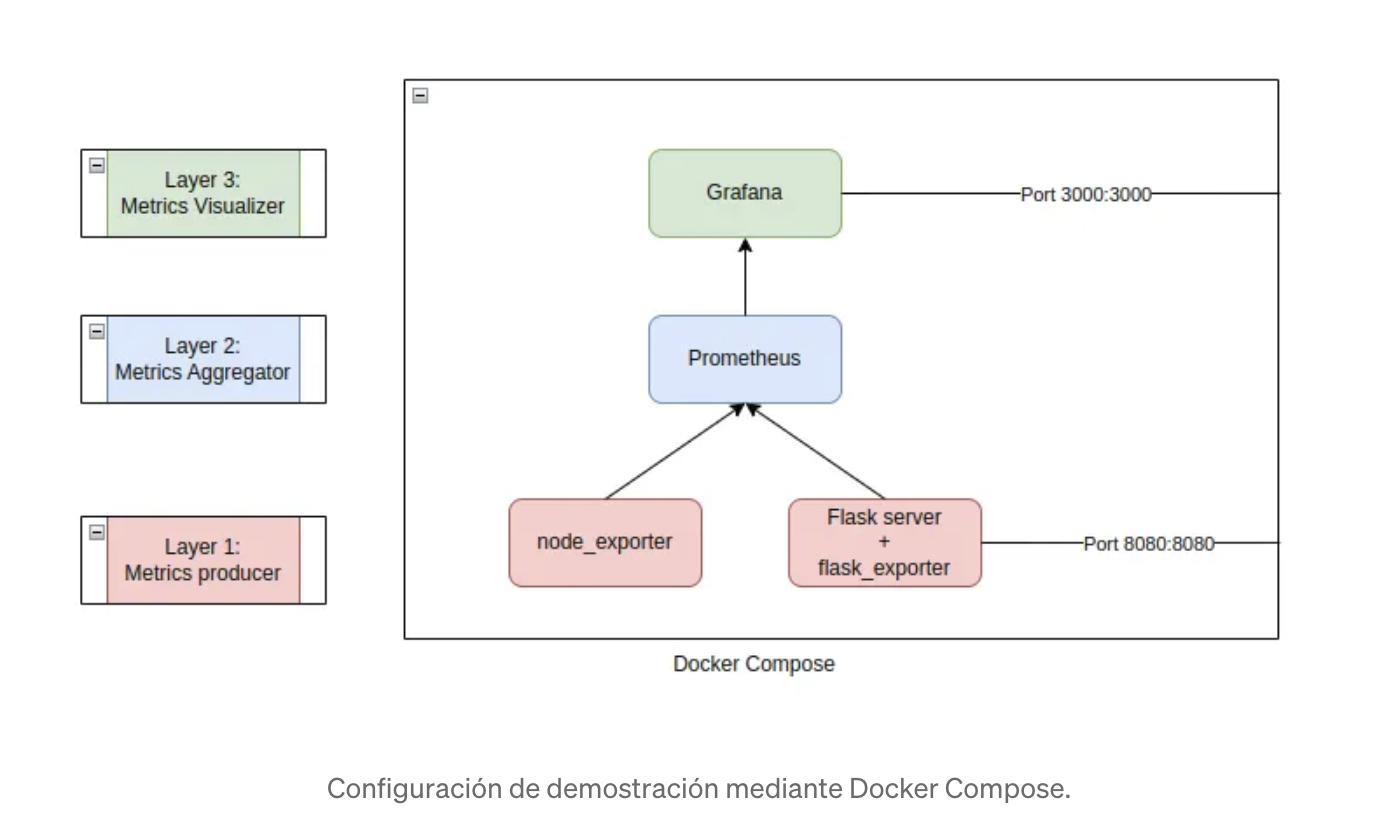

* Capa 1: Productores de métricas. Servicios:
    * flask_exporter: genera métricas relacionadas con la API REST por defecto
    * node_exporter: genera métricas relacionadas con la máquina: uso de CPU, uso de RAM, etc.
* Capa 2: Agregador de métricas
    * servidor Prometheus: sondea las métricas de las capas inferiores y las envia a la capa superior
* Capa 3: Visualizador de métricas
    *  interfaz web de Grafana

## Guía de Monitoreo con Prometheus, Grafana y Python (Flask)

Esta guía detalla el funcionamiento del entorno de monitoreo y métricas configurado localmente

### 1. Servidor Flask

In [1]:
!pip install prometheus_flask_exporter

In [31]:
%%file flask_server_prometheus.py
from flask import Flask,request
from prometheus_flask_exporter import PrometheusMetrics

app = Flask(__name__)
metrics = PrometheusMetrics(app)
metrics.info('app_info', 'Application info', version='1.0.3')

@app.post("/route1")
def postroute1():
    return "Route 1 Post call"

@app.get("/route1")
def getroute1():
    return "Route 1 Get call"

@app.post("/route2")
def postroute2():
    return "Route 2 Post call"

@app.get("/route2")
def getroute2():
    return "Route 2 Get call"

@app.get("/superSecretRoute")
@metrics.do_not_track()
def iamasecretfunction():
    return "Something secret used to be here"

# register additional default metrics
metrics.register_default(
    metrics.counter(
        'by_path_counter', 'Request count by request paths',
        labels={'path': lambda: request.path}
    )
)

Overwriting flask_server_prometheus.py


### 2. Configuración de los servicios

In [32]:
%%file config.yml
global:
  scrape_interval: 3s

  external_labels:
    monitor: "example-app"

rule_files:

scrape_configs:
  - job_name: "prometheus"
    static_configs:
      - targets: ["localhost:9090"]

  - job_name: "node-exporter"
    static_configs:
      - targets: ["node-exporter:9100"]

  - job_name: "python-app"
    static_configs:
      - targets: ["flask-app:8080"]

Overwriting config.yml


In [33]:
%%file docker-compose.yml
version: "3"
services:
  flask-app:
    build: .
    ports:
      - 8080:8080
  node-exporter:
    image: prom/node-exporter:latest
    container_name: node-exporter
    ports:
      - 9100:9100
  prometheus:
    image: prom/prometheus:latest
    container_name: prometheus
    volumes:
      - ./config.yml:/etc/prometheus/prometheus.yml
    ports:
      - 9090:9090
  grafana:
    image: grafana/grafana:latest
    container_name: grafana
    volumes:
      - ./grafana-data:/var/lib/grafana
    user: "0"
    ports:
      - 3000:3000

Overwriting docker-compose.yml


In [34]:
import os                                                                
os.environ["PATH"] += os.pathsep + "/usr/local/bin"

In [35]:
!docker compose up -d --build

WARN[0000] /Users/ppando/Materias/pweb/doc/docker-compose.yml: the attribute `version` is obsolete, it will be ignored, please remove it to avoid potential confusion 
[+] up 0/3
 ⠋ Image prom/prometheus:latest    Pulling                                  0.1s
 ⠋ Image grafana/grafana:latest    Pulling                                  0.1s
 ⠋ Image prom/node-exporter:latest Pulling                                  0.1s
[+] up 0/3
 ⠙ Image prom/prometheus:latest    Pulling                                  0.2s
 ⠙ Image grafana/grafana:latest    Pulling                                  0.2s
 ⠙ Image prom/node-exporter:latest Pulling                                  0.2s
[+] up 0/3
 ⠹ Image prom/prometheus:latest    Pulling                                  0.3s
 ⠹ Image grafana/grafana:latest    Pulling                                  0.3s
 ⠹ Image prom/node-exporter:latest Pulling                                  0.3s
[+] up 0/3
 ⠸ Image prom/prometheus:latest    Pulling                  

* **Exposición de puertos para depuración:** Para facilitar la verificación del estado de los servicios, se expusieron los puertos: 
   * **Prometheus:** Puerto `9090` (mapeado a `localhost:9090`)
   * **Node Exporter:** Puerto `9100` (mapeado a `localhost:9100`)
* **Automatización del arranque:**
* Se levantó el demonio de Docker Desktop en macOS y se iniciaron todos los contenedores en segundo plano.

## Componentes de la Arquitectura

Los siguientes servicios se ejecutan de manera integrada dentro de una red de Docker:
*   **Aplicación Flask ([server.py](file:///Users/ppando/Materias/pweb/descargas/metrics-demo/flask-server/server.py))** -> `localhost:8080`
    *   Usa la librería `prometheus_flask_exporter` para exponer las métricas automáticamente en el endpoint `/metrics`.
    *   Cuenta con una métrica personalizada del tipo contador llamada `by_path_counter` para registrar los accesos detallados por ruta.
*   **Node Exporter** -> `localhost:9100`
    *   Recolecta métricas de hardware y del sistema operativo (uso de CPU, memoria, red, etc.).
*   **Prometheus ([config.yml](file:///Users/ppando/Materias/pweb/descargas/metrics-demo/prometheus/config.yml))** -> `localhost:9090`
    *   Servicio de base de datos temporal que raspa (*scrape*) las métricas cada 3 segundos de los contenedores de Flask, Node Exporter y de sí mismo.
*   **Grafana** -> `localhost:3000`
    *   Herramienta de visualización que se conecta a Prometheus para graficar las métricas.

## Pasos para Probar y Utilizar el Sistema

### 1. Generar tráfico de prueba

Para que se registren métricas en los contadores de la aplicación Flask, realiza algunas llamadas a los endpoints de prueba ejecutando los siguientes comandos en tu consola:

In [39]:
!curl http://localhost:8080/route1

Route 1 Get call

In [17]:
!curl -X POST http://localhost:8080/route1

Route 1 Post call

In [18]:
!curl http://localhost:8080/route2

Route 2 Get call

In [19]:
!curl -X POST http://localhost:8080/route2

Route 2 Post call

Ver las métricas en texto plano:
* metrics = PrometheusMetrics(app)
    * Se encarga de configurar la ruta "/metrics" para exportar todas las métricas recopiladas
    * [Documentación](https://github.com/rycus86/prometheus_flask_exporter/tree/master)

In [40]:
!curl http://localhost:8080/metrics

# HELP python_gc_objects_collected_total Objects collected during gc
# TYPE python_gc_objects_collected_total counter
python_gc_objects_collected_total{generation="0"} 195.0
python_gc_objects_collected_total{generation="1"} 273.0
python_gc_objects_collected_total{generation="2"} 0.0
# HELP python_gc_objects_uncollectable_total Uncollectable objects found during GC
# TYPE python_gc_objects_uncollectable_total counter
python_gc_objects_uncollectable_total{generation="0"} 0.0
python_gc_objects_uncollectable_total{generation="1"} 0.0
python_gc_objects_uncollectable_total{generation="2"} 0.0
# HELP python_gc_collections_total Number of times this generation was collected
# TYPE python_gc_collections_total counter
python_gc_collections_total{generation="0"} 86.0
python_gc_collections_total{generation="1"} 7.0
python_gc_collections_total{generation="2"} 0.0
# HELP python_info Python platform information
# TYPE python_info gauge
python_info{implementation="CPython",major="3",minor="9",patchlev

### 2. Verificar objetivos en Prometheus

[http://localhost:9090/targets](http://localhost:9090/targets)

Se observan los tres objetivos (`python-app`, `node-exporter` y `prometheus`) en estado **`UP`**, lo que confirma que Prometheus está recopilando los datos sin inconvenientes

### 3. Configurar Grafana e importar el Tablero (Dashboard)

1. Abrir la interfaz de Grafana en [http://localhost:3000](http://localhost:3000)
2. Iniciar sesión con las credenciales predeterminadas:
   * **Usuario:** `admin`
   * **Contraseña:** `admin`
3. Agregar **Prometheus** como origen de datos:
   * Ir a **Connections** > **Data Sources** > **Add data source**
   * Elegir **Prometheus**
   * En **Connection** > **Prometheus server URL**, escribir: `http://prometheus:9090`
   * Bajar hasta el final de la pantalla y clic en **Save & test**. Debería confirmar la conexión exitosa
4. Importar el tablero preconfigurado:
   * Ir a **Dashboards** > **New** > **Import dashboard**
   * Copiar el JSON y pegar en el cuadro de texto
   * Clic en **Load**, seleccionar la fuente de datos Prometheus que se acaba de guardar, y clic en **Import**


JSON a importar en el dashboard

## Eliminar las imagenes docker

1. Eliminar el contenedor
2. Eliminar todas las imagenes